In [1]:
import numpy as np
import pandas as pd
import re

In [2]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [3]:
df=pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\Machine learning project\\gurgaon_properties_cleaned_v1.xls")

In [4]:
df.head(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet area: 867.24 sq.ft. (80.57 sq.m.),3,3,2,"study room,pooja room",6.0,West,1 to 5 Year Old,"['Huda Metro Station (Gurugram)', 'Sapphire 83 Mall', 'Naurangpur Road', 'Delhi - Ajmer Expy', 'Bal Bharati Public School–IMT Manesar', 'Amity University Gurugram', 'Miracles Apollo Cradle / Spectra', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']","['6 Wardrobe', '1 Stove', '1 Chimney', '4 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up area: 3655.35 sq.ft. (339.59 sq.m.)Carpet area: 3500 sq.ft. (325.16 sq.m.),4,6,3+,"servant room,pooja room",15.0,East,1 to 5 Year Old,"['Ansal Plaza', 'Dwaraka Expressway', 'First Step Play School', 'Sri Ma Montessori International', 'Jai Sai Ram Hospital', 'Park Hospital', 'IGI Airport', 'Gurgaon Railway Station']","['6 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '9 Light', '6 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
2,flat,signature global park,sohna road,0.95,7846.0,1211.0,Built Up area: 1210.73 (112.48 sq.m.)Carpet area: 756.6 sq.ft. (70.29 sq.m.),3,2,3+,not available,1.0,NaN,1 to 5 Year Old,"['Sector 55-56 metro', 'Global city centre', 'Sohna road dhunela', 'Gd goenka university', 'Maharana pratap school', 'Vardaan hospital and trauma centre', 'Indira Gandhi International Airport', 'Garhi harsaru railway station Gurgaon']",[],"['Security / Fire Alarm', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Water Storage', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center']"
3,house,nirvana cedar crest,sector 50,3.99,8866.0,(418 sq.m.) Plot Area,Plot area 4500(418.06 sq.m.),4,5,3+,servant room,4.0,North-East,0 to 1 Year Old,"['Radhakrishna Shani Mandir', 'Standard chartered ATM', 'Icici bank ATM', 'Vatsalya Clinic', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Vishesh Dental', 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Dr. Naresh Pandita', 'Dr. Anuj Sharma', 'Dr. Aruna Kalra', 'Wellness Eye Centre', 'Skin Clinic', 'Best Urologist Atcomplete Family Clinic', 'Divine Look Clinic Centre', 'Sukhmani 

In [5]:
df['area'] = round((df['price']*10000000)/df['price_per_sqft'])
df['area']

0         1620.0
1         4848.0
2         1211.0
3         4500.0
4         1580.0
5         1650.0
6         1159.0
7         2030.0
8         1640.0
9         1350.0
10        2430.0
11        1755.0
12         472.0
13        1720.0
14        2132.0
15        1950.0
16        1950.0
17         583.0
18        1000.0
19        2606.0
20        1269.0
21         644.0
22        1295.0
23        3844.0
24        2367.0
25        1350.0
26        1105.0
27        2350.0
28        1485.0
29        1805.0
30        1789.0
31        1534.0
32        1125.0
33        2579.0
34        1500.0
35         900.0
36        1538.0
37        2000.0
38         830.0
39        1650.0
40        1275.0
41        1550.0
42        2385.0
43        2217.0
44         650.0
45        1350.0
46        1008.0
47        2103.0
48        1800.0
49         892.0
50        1304.0
51       49123.0
52        2120.0
53        1654.0
54        1505.0
55        1678.0
56        2727.0
57        1910.0
58         366

In [6]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
904,2.45,2132.0,Super Built up area 2132(198.07 sq.m.)Built Up area: 1800 sq.ft. (167.23 sq.m.)Carpet area: 1500 sq.ft. (139.35 sq.m.)
39,1.42,1650.0,Super Built up area 1650(153.29 sq.m.)
3261,4.26,3250.0,Built Up area: 3250 (301.93 sq.m.)
3489,5.90,3375.0,Super Built up area 3363(312.43 sq.m.)
3303,2.52,3150.0,Super Built up area 3150(292.64 sq.m.)Built Up area: 2800 sq.ft. (260.13 sq.m.)Carpet area: 2400 sq.ft. (222.97 sq.m.)


In [7]:
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [8]:
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [9]:
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [12]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [15]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
1567,1.60,flat,2191.0,Super Built up area 2191(203.55 sq.m.)Built Up area: 2000 sq.ft. (185.81 sq.m.)Carpet area: 1800 sq.ft. (167.23 sq.m.),2191.0,2000.0,1800.00
1409,1.55,flat,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet area: 1022.58 sq.ft. (95 sq.m.),1650.0,NaN,1022.58
3266,1.65,flat,1950.0,Carpet area: 1950 (181.16 sq.m.),NaN,NaN,1950.00
814,1.40,flat,1750.0,Super Built up area 1750(162.58 sq.m.)Built Up area: 1466 sq.ft. (136.2 sq.m.),1750.0,1466.0,NaN
1332,2.29,flat,2660.0,Super Built up area 2660(247.12 sq.m.)Carpet area: 2000 sq.ft. (185.81 sq.m.),2660.0,NaN,2000.00


In [21]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [22]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,NaN,NaN
9,2.30,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
10,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
24,3.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
25,1.15,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [23]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            1
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [26]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [31]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,NaN,NaN
9,2.30,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN
10,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,NaN,NaN
24,3.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,NaN,NaN
25,1.15,house,1350.0,Plot area 150(125.42 sq.m.),NaN,NaN,NaN


In [33]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [35]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [37]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [39]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,4500.00,NaN
9,2.30,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
10,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,270.00,NaN
24,3.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,263.00,NaN
25,1.15,house,1350.0,Plot area 150(125.42 sq.m.),NaN,150.00,NaN
32,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,1125.00,NaN
48,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
49,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
73,11.75,house,5056.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
92,1.50,house,1300.0,Plot area 1300(120.77 sq.m.),NaN,1300.00,NaN


In [40]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [43]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale, axis=1)


In [45]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3,3.99,house,4500.0,Plot area 4500(418.06 sq.m.),NaN,4500.00,NaN
9,2.30,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
10,6.00,house,2430.0,Plot area 270(225.75 sq.m.),NaN,2430.00,NaN
24,3.50,house,2367.0,Plot area 263(219.9 sq.m.),NaN,2367.00,NaN
25,1.15,house,1350.0,Plot area 150(125.42 sq.m.),NaN,1350.00,NaN
32,0.65,house,1125.0,Plot area 1125(104.52 sq.m.),NaN,1125.00,NaN
48,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
49,1.60,house,892.0,Plot area 892(82.87 sq.m.),NaN,892.00,NaN
73,11.75,house,5056.0,Plot area 502(419.74 sq.m.),NaN,502.00,NaN
92,1.50,house,1300.0,Plot area 1300(120.77 sq.m.),NaN,1300.00,NaN


In [46]:
# update the original dataframe
df.update(all_nan_df)

In [49]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            1
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [51]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1530
servant room                                      883
study room                                        304
others                                            225
pooja room                                        162
store room                                        105
study room,servant room                           103
pooja room,servant room                            81
servant room,others                                69
servant room,pooja room                            41
pooja room,study room,servant room,others          37
study room,others                                  30
pooja room,study room,servant room                 29
servant room,store room                            26
pooja room,study room                              19
pooja room,study room,servant room,store room      17
study room,pooja room                              13
study room,servant room,store room                 11
servant room,

In [53]:
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col,na=False).astype(int)

In [55]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
906,not available,0,0,0,0,0
3707,"study room,others",1,0,0,0,1
2666,not available,0,0,0,0,0
3338,servant room,0,1,0,0,0
3124,not available,0,0,0,0,0


In [57]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Jun 2024                 7
Aug 2023                 7
Dec 2025                 7
Nov 2023                 5
By 2025                  4
Oct 2023                 4
Sep 2023                 4
Jul 2024                 4
Aug 2024                 4
Nov 2024                 3
Feb 2024                 3
Jan 2025                 3
May 2024                 3
Oct 2025                 2
Jun 2027                 2
Aug 2025                 2
Apr 2026                 2
Mar 2025                 2
Jul 2025                 2
By 2027                  2
Dec 2026                 2
Sep 2025      

In [59]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [61]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [63]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [65]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
2430,[],NaN
2303,"['1 Water Purifier', '1 Exhaust Fan', '1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1506,NaN,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
645,"['1 Water Purifier', '8 Fan', '1 Fridge', '1 Exhaust Fan', '1 Dining Table', '5 Geyser', '1 Stove', '1 Light', '6 AC', '1 TV', '1 Modular Kitchen', '1 Chimney', '9 Curtains', '5 Wardrobe', '1 Sofa', '1 Washing Machine', '1 Microwave', 'No Bed']","['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3346,[],"['Intercom Facility', 'Lift(s)', 'Feng Shui / Vaastu Compliant', 'Swimming Pool', 'Security Personnel', 'Maintenance Staff', 'Park', 'Club house / Community Center', 'Fitness Centre / GYM']"


In [67]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20532\2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [69]:
furnishings_df.shape

(3803, 19)

In [71]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20532\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [73]:
furnishings_df.sample(5)

,AC,Light,Modular Kitchen,Curtains,Washing Machine,Exhaust Fan,Geyser,Fan,TV,Dining Table,Fridge,Stove,Chimney,Wardrobe,Sofa,Microwave,Bed,Water Purifier
2117,1,12,1,0,0,1,2,4,0,1,0,1,1,2,0,0,0,0
3394,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2076,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1038,6,10,0,0,0,0,0,6,0,0,0,0,0,5,0,0,0,0
3535,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [75]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20532\2445438592.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [77]:
furnishings_df.shape

(3803, 19)

In [79]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_20532\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [81]:
furnishings_df.sample(5)

,AC,Light,Modular Kitchen,Curtains,Washing Machine,Exhaust Fan,Geyser,Fan,TV,Dining Table,Fridge,Stove,Chimney,Wardrobe,Sofa,Microwave,Bed,Water Purifier
600,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
2018,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
910,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3046,0,10,0,0,0,0,0,4,0,0,0,0,0,3,0,0,0,0
3153,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [83]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [84]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [85]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

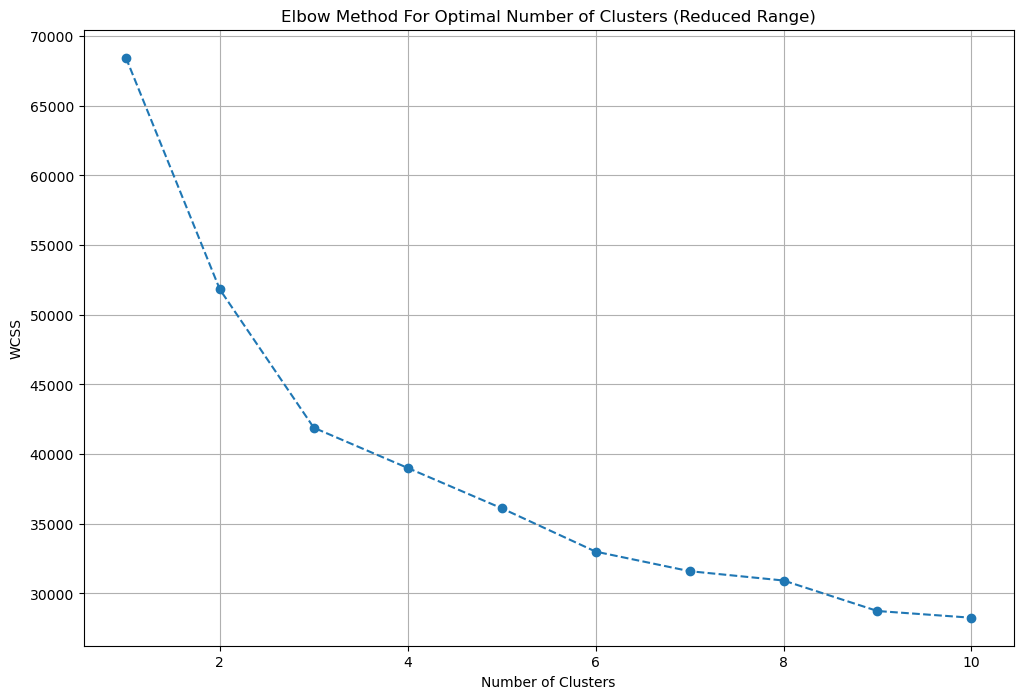

In [86]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [87]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [88]:
df = df.iloc[:,:-18]

In [89]:
df['furnishing_type'] = cluster_assignments

In [90]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished


,furnishDetails,furnishing_type
3674,NaN,0
1196,"['4 Fan', '1 Exhaust Fan', '2 Geyser', '4 Light', '3 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",1
2857,"['1 Modular Kitchen', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3726,"['9 Fan', '10 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",0
3327,NaN,0


In [91]:
df[['society','features']].sample(5)

,society,features
844,ss the leaf,"['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'No open drainage around', 'Bank Attached Property', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
92,independent,NaN
1746,antriksh heights,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Separate entry for servant room', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Fitness Centre / GYM', 'Club house / Community Center', 'Water softening plant']"
2171,elan mercado,"['Power Back-up', 'Lift(s)', 'Swimming Pool', 'Maintenance Staff', 'Park', 'Security Personnel', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']"
1869,suncity platinum towers,"['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Park', 'Fitness Centre / GYM', 'Club house / Community Center']"


In [92]:
df['features'].isnull().sum()

635

In [94]:
import pandas as pd
app_df = pd.read_csv("C:\\Users\\LENOVO\\OneDrive\\Desktop\\Machine learning project\\appartments.csv")
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [96]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [98]:
temp_df = df[df['features'].isnull()]

In [100]:
temp_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
12,house,rattan garden,sector 7,0.83,17584.0,472.0,Carpet area: 472 (43.85 sq.m.),5,3,2,not available,3.0,East,Undefined,"['Chintapurni Mandir', 'Aryan Hospital', 'D.R. Rajnis Gupta Clinic', 'Geeta Nursing Home Gurgaon', 'Ravi Clinic and Health Care Centre', 'Sparsh Hospital Gurgaon', 'Bhatnagar Maternity and Nursing Home', 'Gurgaon Eye Centre', 'Chiranjiv Hospital', 'Bindal Clinic', 'Pearl Dental Clinic', 'M.S Hospital', 'Taneja Hospital', 'Dr. Sarvejeet Singh', 'My Care Clinic', 'Centre For Sight Gurgaon New Railway Road', 'Triveni Hospital Gurgaon', 'Kidney Clinic', 'Dr. Ashok Jain', 'Swastik Maternity and Medical Centre', 'Dr. Agya Ram Sharma Clinic', 'Kharbanda Maternity and Nursing Home', 'Lalit Dental Care', 'Dr. Madan Clinic', 'Dentecare - Multispeciality Dental Clinic', 'Lall Eye Care Centre', 'Om Charitable Dental & Implant Centre', 'Lall Nursing and Maternity Home', 'M Goel Hospital', 'Dev Man Kathuria Clinic', 'Gupta Hospital Gurgaon', 'Jackson Hospital', 'Dental Health Centre', 'Satyam Hospital Gurgaon', 'Dr. Ajay S. Gupta Clinic', 'Sarvodya Hospital', 'GH Gurgaon', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Nova Care Clinic', 'Verma E.N.T. Hospital', 'Rajiv Memorial Eye Infirmary Jacobpura', 'Dr. Sindhu Clinic', 'Sharma Hospital Gurgaon', 'State bank of india', 'Hdfc bank', 'Kotak bank', 'Indian bank', 'Pizza Hut', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College']",NaN,NaN,NaN,NaN,472.0,0,0,0,0,0,0
35,house,independent,sector 7,0.53,5888.0,900.0,Built Up area: 900 (83.61 sq.m.),2,2,0,not available,1.0,NaN,Undefined,NaN,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,900.0,NaN,0,0,0,0,0,0
46,house,independent,sector 3,0.90,8928.0,1008.0,Built Up area: 1008 (93.65 sq.m.),3,1,0,not available,1.0,NaN,Undefined,"['Palam Vihar Vyapar kendra', 'Palam triangle', 'Chintapurni Mandir', 'Sheetla Mata Mandir', 'State bank ATM', 'Jiya Clinic', 'Dr. Mittal Clinic', 'Chirag Hospital Pvt. Ltd', ""Dr. Anurag's Child Care Clinic"", 'R K Hospital Gurgaon', 'Sneh Hospital Gurgaon', 'Yashroop Medical Centre', 'Bhardwaj Hospital', 'Dr. Sindhu Clinic', 'Dr. Hitesh Dawar', 'Sarvodya Hospital', 'Jain Sant Phool Chand Ji Charitable Hospital', 'Kalyan Hospital Gurgaon', 'Prateek Nursing Home And Polyclinic', 'Gurgaon Eye Centre', 'Kr Dental Hub', 'GH Gurgaon', 'Dr. Agya Ram Sharma Clinic', 'Jeevan Jyoti Hospital Gurgaon', 'Sparsh Hospital Gurgaon', 'Aryan Hospital', 'Dr. Ashok Jain', 'Shree Krishna Hospital Gurgaon', 'D.R. Rajnis Gupta Clinic', 'Children Hospital', 'Dr. Tomar Clinic', 'Bhatnagar Maternity and Nursing Home', 'Nidhi Clinic', 'Dr. Babita Sharma', 'Pearl Dental Clinic', 'Sheetla Clinic', 'Dr. Sarvejeet Singh', 'Geeta Nursing Home Gurgaon', 'Indian bank', 'Kotak bank', 'Hdfc bank', 'Pizza Hut', ""McDonald's"", 'Lieutenant Atul Kataria School', 'St. Michaels Sr. Sec. School', 'Dronacharya Government College', 'Gurgaon railway station', 'Gurgaon railway station', 'Gurgaon railway station']","['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']",NaN,NaN,1008.0,NaN,0,0,0,0,0,0
54,flat,raheja vedaanta,sector 108,0.70,4651.0,1505.0,Built Up area: 1505 (139.82 sq.m.),2,2,2,not available,12.0,South,Undefined,NaN,"['1 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust 

In [102]:
temp_df.shape

(635, 26)

In [104]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [106]:
df.loc[temp_df.index,'features'] = x.values

In [108]:
df['features'].isnull().sum()

481

In [110]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast


In [112]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [114]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2069,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0
2082,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
627,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
1836,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0
3526,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0


In [116]:
features_binary_df.shape

(3803, 130)

In [118]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

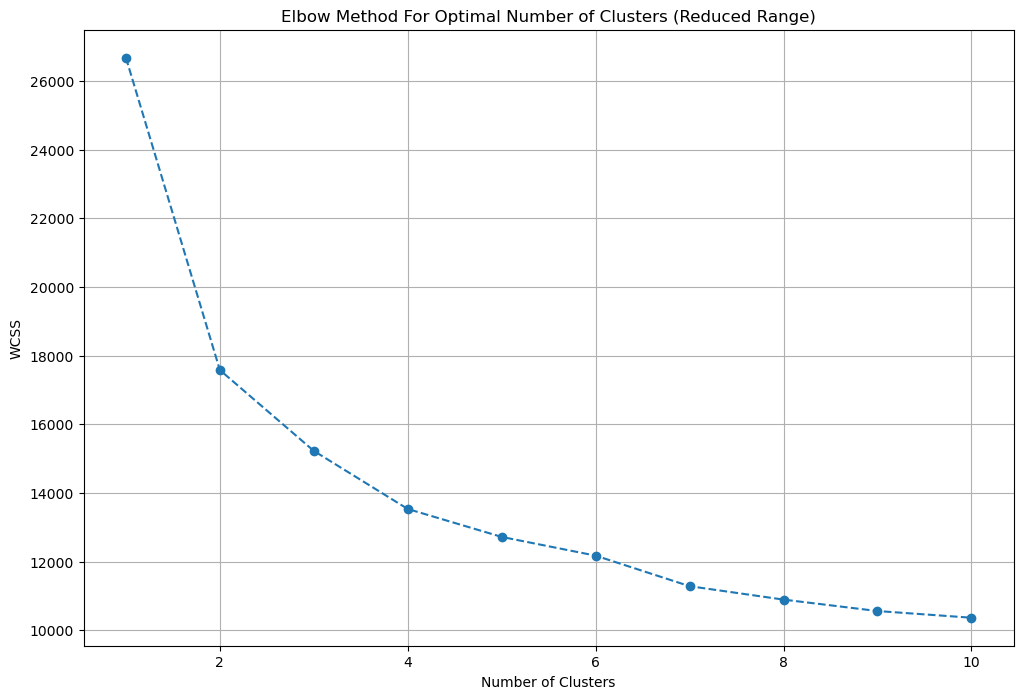

In [120]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [122]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [124]:
df['luxury_score'] = luxury_score

In [126]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,flat,mapsko mount ville,sector 79,1.30,8024.0,1620.0,Super Built up area 1620(150.5 sq.m.)Carpet area: 867.24 sq.ft. (80.57 sq.m.),3,3,2,"study room,pooja room",6.0,West,Relatively New,"['Huda Metro Station (Gurugram)', 'Sapphire 83 Mall', 'Naurangpur Road', 'Delhi - Ajmer Expy', 'Bal Bharati Public School–IMT Manesar', 'Amity University Gurugram', 'Miracles Apollo Cradle / Spectra', 'Indira Gandhi Intl Airport', 'Garhi Harsaru Junction']","['6 Wardrobe', '1 Stove', '1 Chimney', '4 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'No open drainage around', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1620.0,NaN,867.24,1,0,0,1,0,0,"[Centrally Air Conditioned, Water purifier, Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, Water Storage, No open drainage around, Piped-gas, Internet/wi-fi connectivity, Recently Renovated, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Low Density Society, Waste Disposal, Rain Water Harvesting, Water softening plant, Shopping Centre, Fitness Centre / GYM, Club house / Community Center]",151
1,flat,experion windchants,sector 112,5.20,10726.0,4848.0,Super Built up area 4848(450.39 sq.m.)Built Up area: 3655.35 sq.ft. (339.59 sq.m.)Carpet area: 3500 sq.ft. (325.16 sq.m.),4,6,3+,"servant room,pooja room",15.0,East,Relatively New,"['Ansal Plaza', 'Dwaraka Expressway', 'First Step Play School', 'Sri Ma Montessori International', 'Jai Sai Ram Hospital', 'Park Hospital', 'IGI Airport', 'Gurgaon Railway Station']","['6 Fan', '1 Exhaust Fan', '3 Geyser', '1 Stove', '9 Light', '6 AC', '1 Modular Kitchen', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",4848.0,3655.350000,3500.00,0,1,0,1,0,1,"[Centrally Air Conditioned, Water purifier, Security / Fire Alarm, Power Back-up, Feng Shui / Vaastu Compliant, Private Garden / Terrace, Intercom Facility, Lift(s), High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connecti

In [128]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [130]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2966,house,rattan garden,sector 7,1.30,13499.0,963.0,Built Up area: 963 (89.47 sq.m.),5,3,2,3.0,NaN,Old Property,NaN,963.0,NaN,0,1,0,0,0,0,0
1159,flat,dlf the primus,sector 82a,2.55,11218.0,2273.0,Super Built up area 2273(211.17 sq.m.)Carpet area: 1340 sq.ft. (124.49 sq.m.),4,4,3+,14.0,South-West,Relatively New,2273.0,NaN,1340.0,0,0,0,0,0,2,44
1116,flat,bptp astaire gardens,sector 70a,1.20,7058.0,1700.0,Super Built up area 1700(157.94 sq.m.)Built Up area: 1450 sq.ft. (134.71 sq.m.),3,3,3+,2.0,NaN,Relatively New,1700.0,1450.0,NaN,0,0,0,0,0,2,38
1480,house,independent,sector 26,4.50,33333.0,1350.0,Plot area 150(125.42 sq.m.),5,5,3+,2.0,NaN,Old Property,NaN,1350.0,NaN,0,1,0,0,0,0,7
217,flat,dlf the primus,sector 82a,2.70,10481.0,2576.0,Super Built up area 2576(239.32 sq.m.)Carpet area: 1306 sq.ft. (121.33 sq.m.),4,4,3+,18.0,East,Moderately Old,2576.0,NaN,1306.0,0,1,0,0,0,0,38


In [132]:
df.shape

(3803, 23)

In [134]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)